In [3]:
import os
import tarfile
import urllib.request

DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    os.makedirs(housing_path, exist_ok=True)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    with tarfile.open(tgz_path) as housing_tgz:
        housing_tgz.extractall(path=housing_path)

# Run it
fetch_housing_data()
print("Done! Files extracted to:", HOUSING_PATH)

Done! Files extracted to: datasets\housing


C:\Users\samuel.an\AppData\Local\Temp\ipykernel_10192\152279015.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tgz.extractall(path=housing_path)


In [4]:
import pandas as pd

def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

In [5]:
housing = load_housing_data()
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


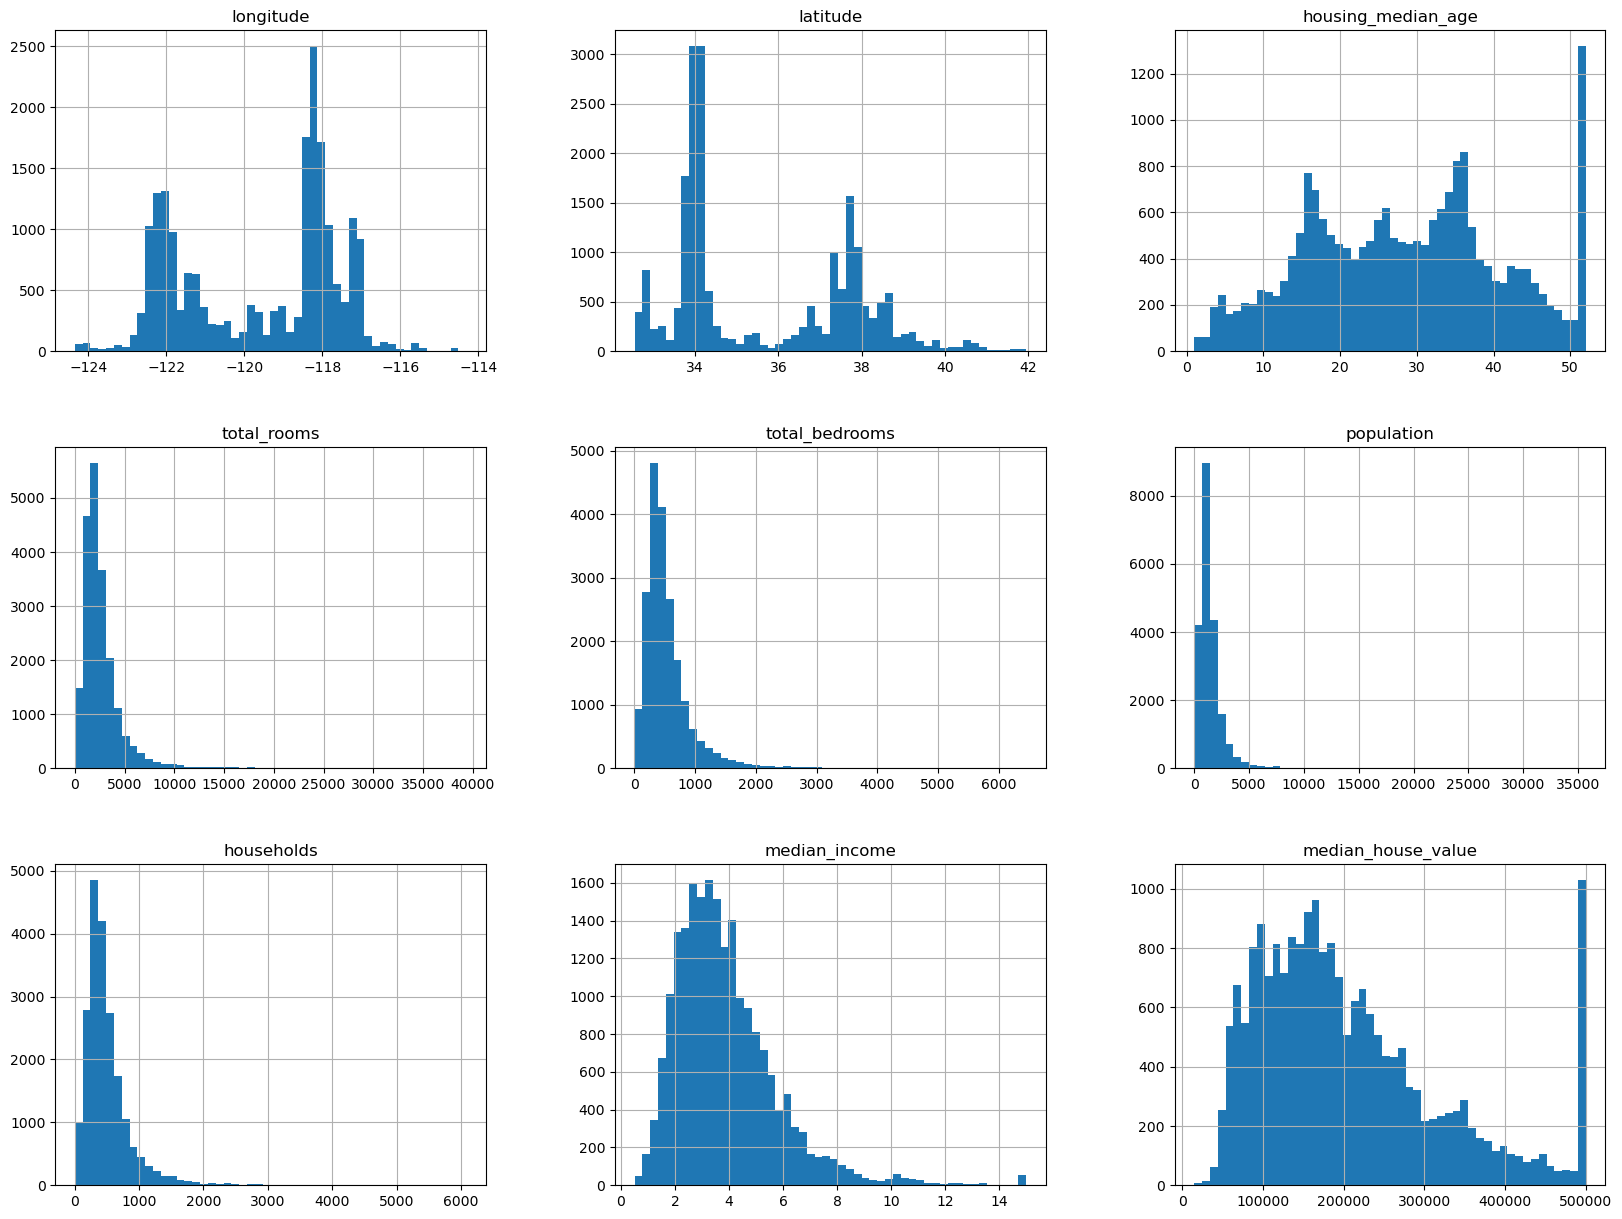

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(20,15))
plt.show()

In [7]:
import numpy as np

def split_train_test(data, test_ratio, seed=None):
    if seed is not None:
        np.random.seed(seed)
        
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    
    return data.iloc[train_indices], data.iloc[test_indices]

In [8]:
import os
import tarfile
import urllib.request
import pandas as pd
import numpy as np

# Paths/URLs
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

# Download + extract dataset
def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    os.makedirs(housing_path, exist_ok=True)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    with tarfile.open(tgz_path) as housing_tgz:
        housing_tgz.extractall(path=housing_path)

# Load CSV into a pandas DataFrame
def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

# Split into train/test sets
def split_train_test(data, test_ratio, seed=42):
    np.random.seed(seed)
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

# Run everything
fetch_housing_data()                  # downloads + extracts (safe to run again)
housing = load_housing_data()         # loads housing.csv
train_set, test_set = split_train_test(housing, 0.2, seed=42)

# Check results
print("Housing shape:", housing.shape)
print("Train set:", len(train_set))
print("Test set:", len(test_set))
print()
print(housing.head())

Housing shape: (20640, 10)
Train set: 16512
Test set: 4128

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


C:\Users\samuel.an\AppData\Local\Temp\ipykernel_10192\2003705615.py:18: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tgz.extractall(path=housing_path)


WEEK 4:

<Axes: >

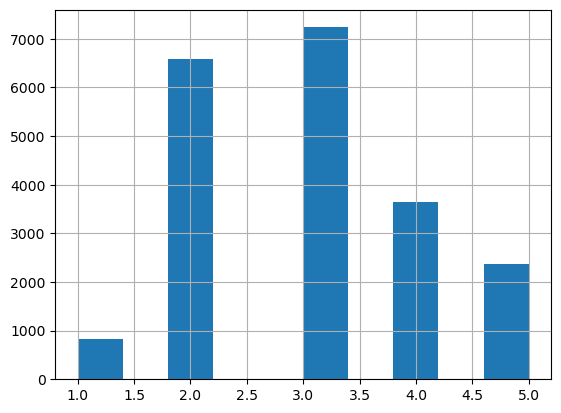

In [9]:
housing["income_cat"] = pd.cut(housing["median_income"],
bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
labels=[1, 2, 3, 4, 5])

housing["income_cat"].hist()

<Axes: xlabel='longitude', ylabel='latitude'>

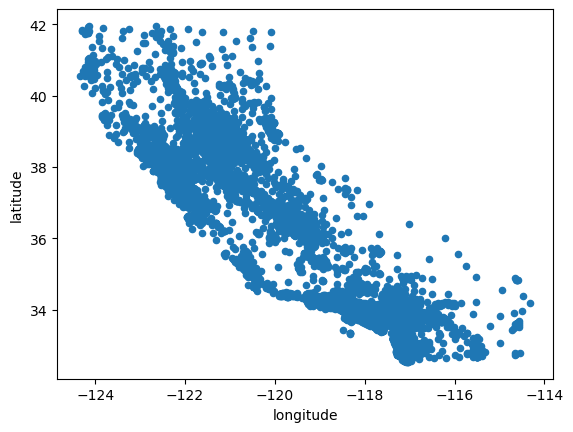

In [10]:
housing.plot(kind="scatter", x="longitude", y="latitude")

<Axes: xlabel='longitude', ylabel='latitude'>

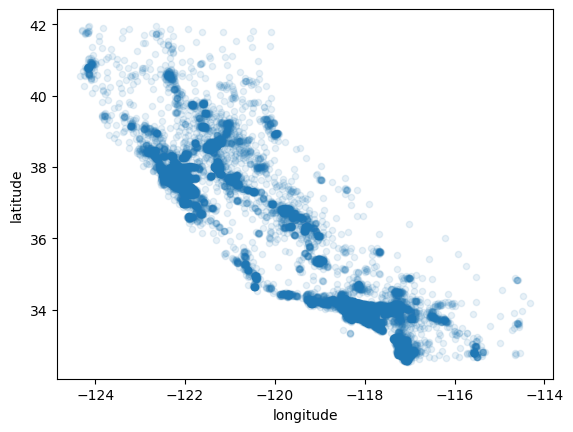

In [11]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)

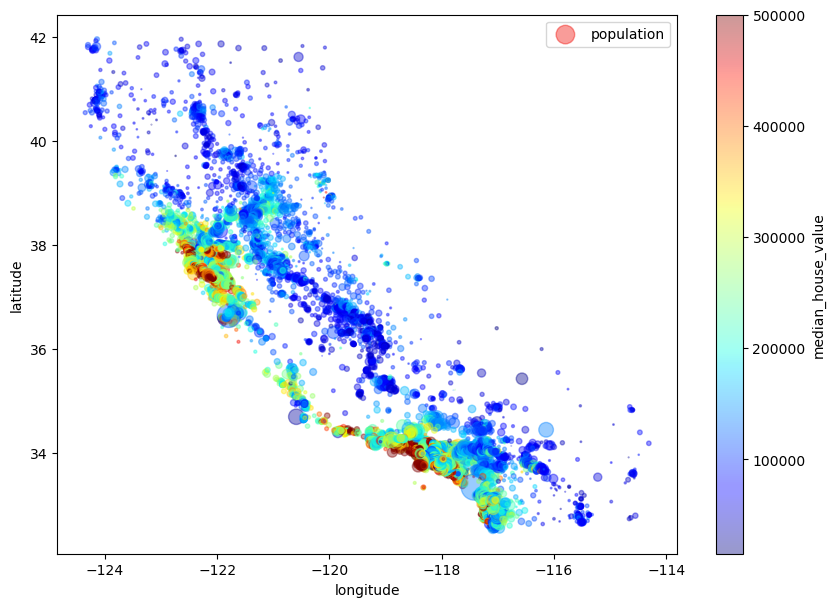

In [12]:
import matplotlib.pyplot as plt
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
s=housing["population"]/100, label="population", figsize=(10,7),
c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
)
plt.legend()

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

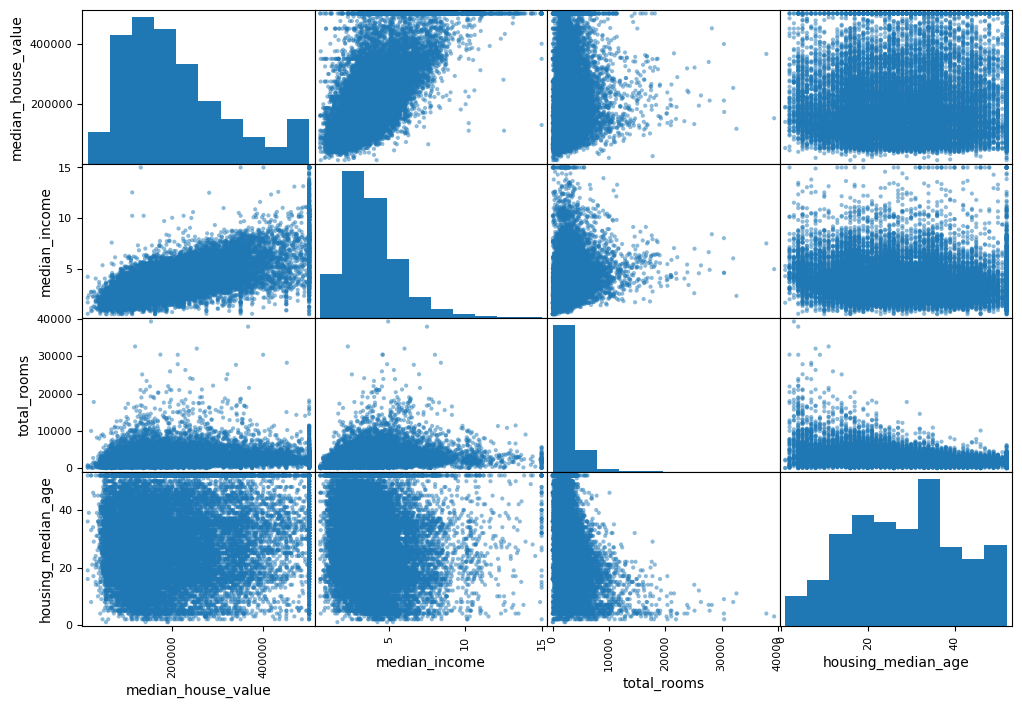

In [13]:
from pandas.plotting import scatter_matrix
attributes = ["median_house_value", "median_income", "total_rooms",
"housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))

In [14]:
corr_matrix = housing.select_dtypes(include='number').corr()
corr_matrix["median_house_value"].sort_values(ascending=False)


median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

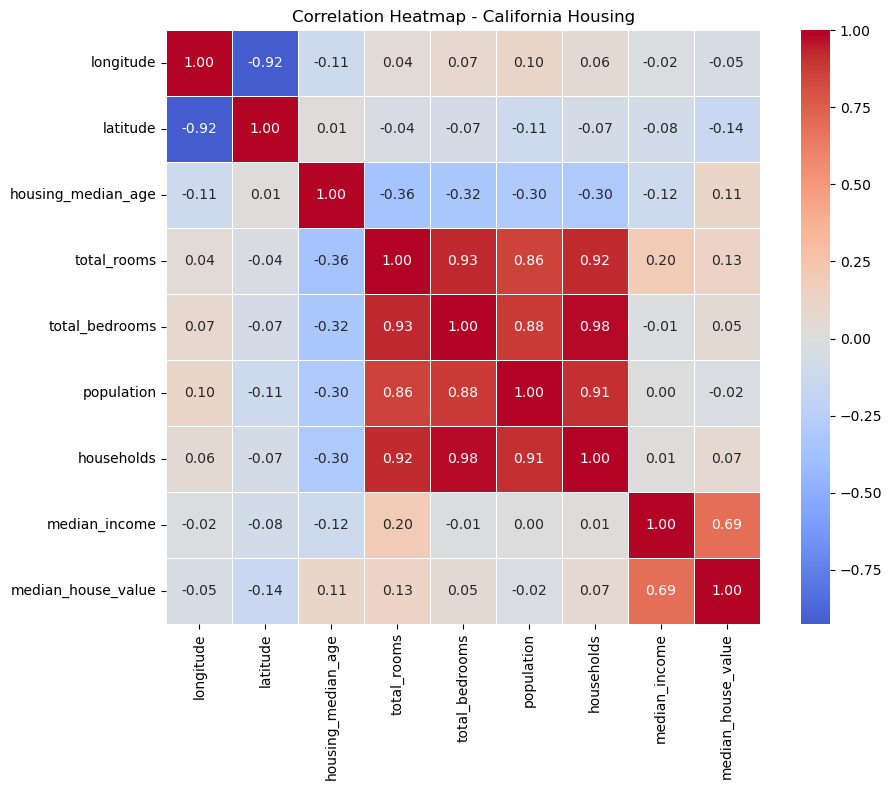

In [15]:
# Correlation Heatmap
import seaborn as sns

numeric_housing = housing.select_dtypes(include='number')
corr_matrix = numeric_housing.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, square=True)
plt.title("Correlation Heatmap - California Housing")
plt.tight_layout()
plt.show()

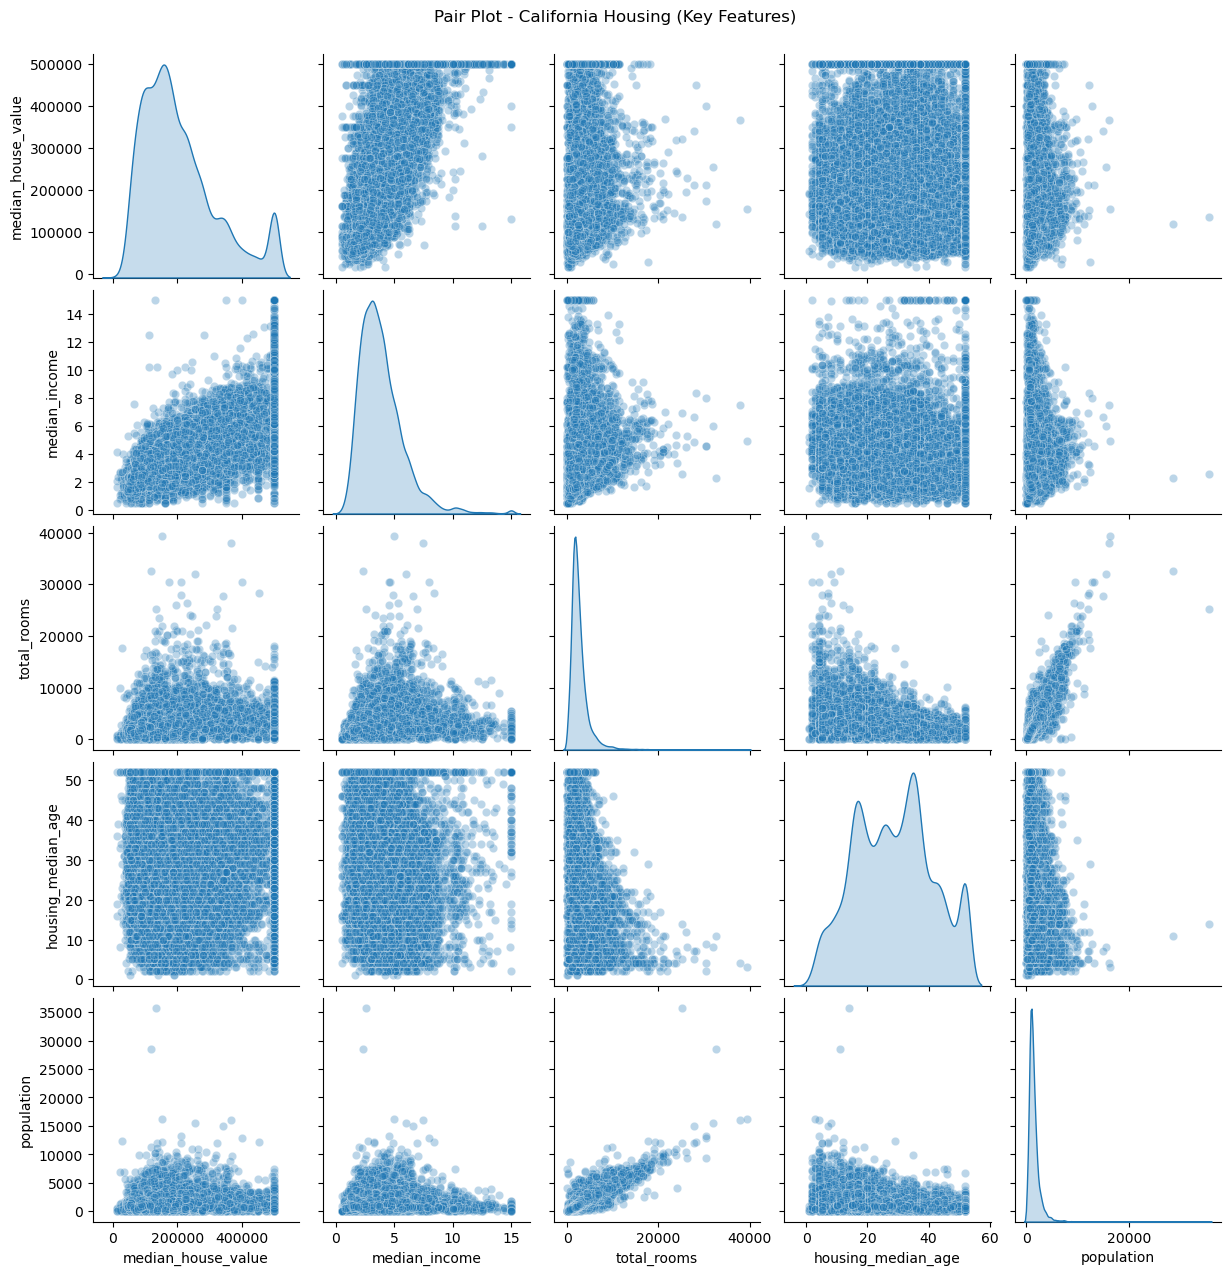

In [16]:
# Pair Plot - key features most correlated with median_house_value
key_cols = ["median_house_value", "median_income", "total_rooms", "housing_median_age", "population"]
sns.pairplot(housing[key_cols].dropna(), diag_kind="kde", plot_kws={"alpha": 0.3})
plt.suptitle("Pair Plot - California Housing (Key Features)", y=1.02)
plt.show()

Week 4: 

1. Redundancy variables: total_rooms, total_bedrooms, households, and population are all very similar variables. Adding all four to the model would not provide any meaningful result, creating a shared variable to measure correlation between all four would prove to be more useful in the context of the model.
Hypothesis: Creating a shared variable would increase correlation and fluency in the model

2. Highest correlation/logic: median_house_value and median_income have the highest correlation between two variables, 0.69. This correlation value makes the most sense in the scope of the model, and could be used as the two driving variables for the entire model. 
Hypothesis: These two variables, having the highest correlation, are the variables that would serve the best to create our model. Higher income means a higher house value per district.

3. District age. district_age and median_house_value can serve as a good indication of average housing price. Higher district age typically correlates to higher house value because of a striving economy and average income. E.x - Los Angeles, San Diego, and San Francisco have an older district_age which correlates to house value because of busier economies and higher income averages.
Hypothesis: District age based on logical analysis can serve as a good measure for district prices on average.

In [17]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

# Remove the income_cat column (it was only used for stratification)
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)


In [18]:
housing.dropna(subset=["total_bedrooms"]) # option 1
housing.drop("total_bedrooms", axis=1) # option 2
median = housing["total_bedrooms"].median() # option 3
housing["total_bedrooms"].fillna(median, inplace=True)

C:\Users\samuel.an\AppData\Local\Temp\ipykernel_10192\867637120.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing["total_bedrooms"].fillna(median, inplace=True)


In [21]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
housing_num = housing.drop("ocean_proximity", axis=1)
imputer.fit(housing_num)

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [26]:
X = imputer.transform(housing_num)
housing_tr = pd.DataFrame(X, columns=housing_num.columns,
index=housing_num.index)

Question for CPT Hedglin: break down imputer in depth

In [27]:
print("=== BEFORE: Summary Stats ===")
print(strat_train_set.describe())
print("\nMissing values:\n", strat_train_set.isnull().sum())


=== BEFORE: Summary Stats ===
          longitude      latitude  housing_median_age   total_rooms  \
count  16512.000000  16512.000000        16512.000000  16512.000000   
mean    -119.575635     35.639314           28.653404   2622.539789   
std        2.001828      2.137963           12.574819   2138.417080   
min     -124.350000     32.540000            1.000000      6.000000   
25%     -121.800000     33.940000           18.000000   1443.000000   
50%     -118.510000     34.260000           29.000000   2119.000000   
75%     -118.010000     37.720000           37.000000   3141.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    16354.000000  16512.000000  16512.000000   16512.000000   
mean       534.914639   1419.687379    497.011810       3.875884   
std        412.665649   1115.663036    375.696156       1.904931   
min          2.000000      3.000000      2.000000       0.

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import numpy as np
import pandas as pd

# --- Separate features and labels ---
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

# --- Engineer new features (justify below) ---
housing = housing.copy()
housing["rooms_per_household"]    = housing["total_rooms"]    / housing["households"]
housing["bedrooms_per_room"]      = housing["total_bedrooms"] / housing["total_rooms"]
housing["population_per_household"] = housing["population"]  / housing["households"]

# Justification:
#   rooms_per_household    → raw total_rooms is meaningless without household count; 
#                            a district with 10k rooms but 5k households differs from 
#                            one with 10k rooms and 500 households.
#   bedrooms_per_room      → higher ratio → less spacious → lower value expected.
#   population_per_household → measures crowding density, a known price signal.

# --- Define column groups ---
num_attribs = [
    "longitude", "latitude", "housing_median_age",
    "total_rooms", "total_bedrooms", "population", "households", "median_income",
    "rooms_per_household", "bedrooms_per_room", "population_per_household"
]
cat_attribs = ["ocean_proximity"]

# --- Pipelines ---
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),   # fills ~200 missing total_bedrooms
    ("scaler",  StandardScaler()),                   # zero mean, unit variance
])

cat_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore")),  # 5 ocean categories → 5 binary cols
])

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

# --- Fit + transform ---
housing_prepared = full_pipeline.fit_transform(housing)

print("Shape after preprocessing:", housing_prepared.shape)


Shape after preprocessing: (16512, 16)


In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import numpy as np
import pandas as pd

# --- Separate features and labels ---
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

# --- Engineer new features (justify below) ---
housing = housing.copy()
housing["rooms_per_household"]    = housing["total_rooms"]    / housing["households"]
housing["bedrooms_per_room"]      = housing["total_bedrooms"] / housing["total_rooms"]
housing["population_per_household"] = housing["population"]  / housing["households"]

# Justification:
#   rooms_per_household    → raw total_rooms is meaningless without household count; 
#                            a district with 10k rooms but 5k households differs from 
#                            one with 10k rooms and 500 households.
#   bedrooms_per_room      → higher ratio → less spacious → lower value expected.
#   population_per_household → measures crowding density, a known price signal.

# --- Define column groups ---
num_attribs = [
    "longitude", "latitude", "housing_median_age",
    "total_rooms", "total_bedrooms", "population", "households", "median_income",
    "rooms_per_household", "bedrooms_per_room", "population_per_household"
]
cat_attribs = ["ocean_proximity"]

# --- Pipelines ---
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),   # fills ~200 missing total_bedrooms
    ("scaler",  StandardScaler()),                   # zero mean, unit variance
])

cat_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore")),  # 5 ocean categories → 5 binary cols
])

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

# --- Fit + transform ---
housing_prepared = full_pipeline.fit_transform(housing)

print("Shape after preprocessing:", housing_prepared.shape)


Shape after preprocessing: (16512, 16)


In [30]:
# Reconstruct as DataFrame for readability
cat_cols = full_pipeline.named_transformers_["cat"]["encoder"].get_feature_names_out(cat_attribs)
all_cols  = num_attribs + list(cat_cols)

housing_prepared_df = pd.DataFrame(housing_prepared, columns=all_cols)

print("=== AFTER: Summary Stats (numeric features) ===")
print(housing_prepared_df[num_attribs].describe().round(3))

print("\n=== Before vs After: median_income ===")
print(f"  Before — mean: {housing['median_income'].mean():.3f}, std: {housing['median_income'].std():.3f}")
print(f"  After  — mean: {housing_prepared_df['median_income'].mean():.3f}, std: {housing_prepared_df['median_income'].std():.3f}")

print("\n=== Engineered Features (sample) ===")
print(housing_prepared_df[["rooms_per_household","bedrooms_per_room","population_per_household"]].describe().round(3))


=== AFTER: Summary Stats (numeric features) ===
       longitude   latitude  housing_median_age  total_rooms  total_bedrooms  \
count  16512.000  16512.000           16512.000    16512.000       16512.000   
mean       0.000      0.000               0.000       -0.000          -0.000   
std        1.000      1.000               1.000        1.000           1.000   
min       -2.385     -1.450              -2.199       -1.224          -1.295   
25%       -1.111     -0.795              -0.847       -0.552          -0.579   
50%        0.532     -0.645               0.028       -0.235          -0.246   
75%        0.782      0.973               0.664        0.242           0.261   
max        2.630      2.952               1.857       17.162          13.817   

       population  households  median_income  rooms_per_household  \
count   16512.000   16512.000      16512.000            16512.000   
mean       -0.000      -0.000         -0.000               -0.000   
std         1.000       

WEEK 5:
Logic:
    I wanted to create a before snapshot of all of the present data within the set. There are many errors, gaps, voids that can cause all kinds of potential error when actually making this model. The purpose of filtering the data is to ensure accurate results for each iteration of test and train data sets. Creating a snapshot of the data before gives a good representation of what changed from before to after.

    Cleaning:
    I want to the get the best variables possible, and remove all the noise that will distract this model from doing its job efficiently. median_house_value is the true predictor variable, what we are trying to solve for so removing it as an input serves true. 3 new columns, essentially creating ratios of the variables such as rooms PER household in the district and bedrooms PER rooms etc. This removes some noise when trying to iterate through all of the variables. Notice in total_bedrooms, approximately 200 rows have no value. This will cause error. Take the median value of the column and fill in for those empty rows. Text to binary allows for easy translation from words to machine on how to classify ocean_proximity. It is either 1, yes near the bay or 0, not near the bay. This removes noise. The last and most important is scaling the numbers to all be somewhat uniform. example, median_income ranges from 1-15 while total_rooms ranges from 1-40,000. The model will automatically think total_rooms is the most important because of how much data it contains, while that is not true. Scaling will help remove predictions made by the model based on number of data.
    
